<a href="https://colab.research.google.com/github/HooroBoy/Pemes/blob/main/JS05/JS05_Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Memuat dan Eksplorasi Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Membaca dataset
df = pd.read_csv('/content/voice.csv')
display(df.head())
print(df.info())
print(df['label'].value_counts())

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

### 2. Pra-pemrosesan & Pemilihan Fitur Optimal
Kita akan mengubah label menjadi numerik (0 untuk female, 1 untuk male), lalu mengevaluasi korelasi fitur terhadap target untuk memilih fitur yang paling informatif (memiliki korelasi yang kuat).

Korelasi Fitur dengan Label:
meanfun    -0.833921
Q25        -0.511455
centroid   -0.337415
meanfreq   -0.337415
median     -0.283919
maxdom     -0.195657
mindom     -0.194974
dfrange    -0.192213
meandom    -0.191067
mode       -0.171775
maxfun     -0.166461
minfun     -0.136692
modindx     0.030801
skew        0.036627
Q75         0.066906
kurt        0.087195
sfm         0.357499
sd          0.479539
sp.ent      0.490552
IQR         0.618916
label       1.000000
Name: label, dtype: float64


/tmp/ipykernel_999/445956992.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.index, y=correlations.values, palette='coolwarm')


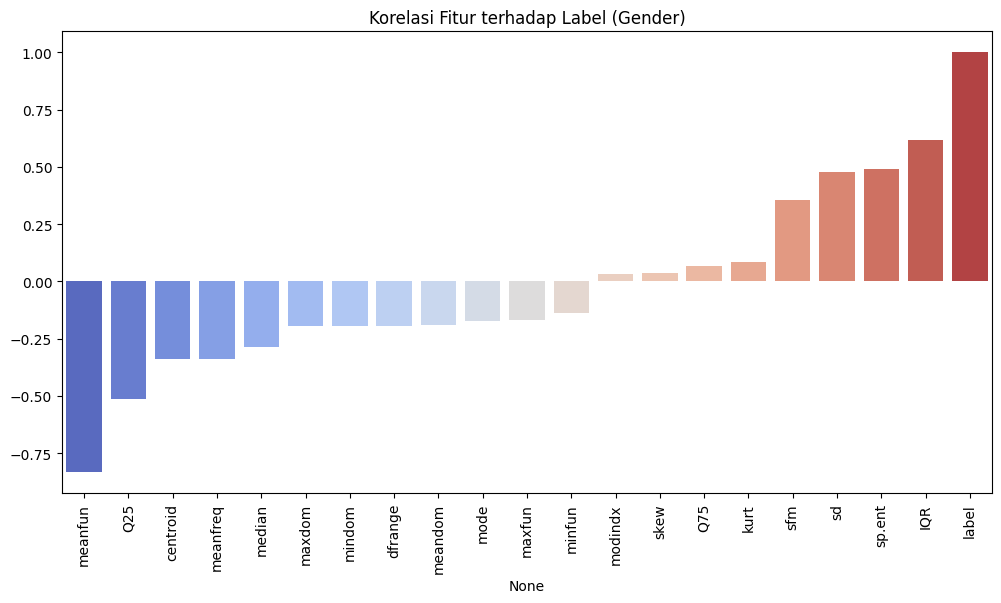

In [2]:
# Encoding label: male -> 1, female -> 0
df['label'] = df['label'].map({'male': 1, 'female': 0})

# Hitung korelasi semua fitur dengan label
correlations = df.corr()['label'].sort_values()
print("Korelasi Fitur dengan Label:")
print(correlations)

# Visualisasi Korelasi
plt.figure(figsize=(12, 6))
sns.barplot(x=correlations.index, y=correlations.values, palette='coolwarm')
plt.xticks(rotation=90)
plt.title("Korelasi Fitur terhadap Label (Gender)")
plt.show()

Berdasarkan korelasi, fitur seperti `meanfun` memiliki korelasi negatif yang sangat kuat dengan label (artinya nilai `meanfun` yang lebih tinggi sangat cenderung mengarah ke female). Sebaliknya, fitur seperti `IQR` (Interquartile Range) memiliki korelasi positif yang cukup kuat.

Mari kita lakukan uji coba performa k-NN menggunakan:
1. Semua Fitur.
2. Fitur Terpilih (Fitur dengan korelasi absolut tinggi, misalnya: `meanfun`, `IQR`, `sd`, `sp.ent`, `sfm`).

In [3]:
# Skenario 1: Semua Fitur
X_all = df.drop('label', axis=1)
y = df['label']

# Skenario 2: Fitur Terpilih (Korelasi Absolut > 0.3)
optimal_features = ['meanfun', 'IQR', 'sd', 'sp.ent', 'sfm', 'meanfreq', 'centroid']
X_opt = df[optimal_features]

def evaluate_knn(X, y, title):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    print(f"Akurasi {title} (k=5): {acc:.4f}")
    return X_train_scaled, X_test_scaled, y_train, y_test

print("--- PERBANDINGAN FITUR ---")
_, _, _, _ = evaluate_knn(X_all, y, "Semua Fitur")
X_train_opt, X_test_opt, y_train, y_test = evaluate_knn(X_opt, y, "Fitur Optimal Terpilih")

--- PERBANDINGAN FITUR ---
Akurasi Semua Fitur (k=5): 0.9763
Akurasi Fitur Optimal Terpilih (k=5): 0.9811


### 3. Mencari Nilai $k$ Terbaik
Menggunakan subset fitur optimal yang telah kita tentukan di atas, mari kita uji nilai $k$ dari 1 hingga 30 untuk melihat performa akurasi terbaik pada data pengujian.

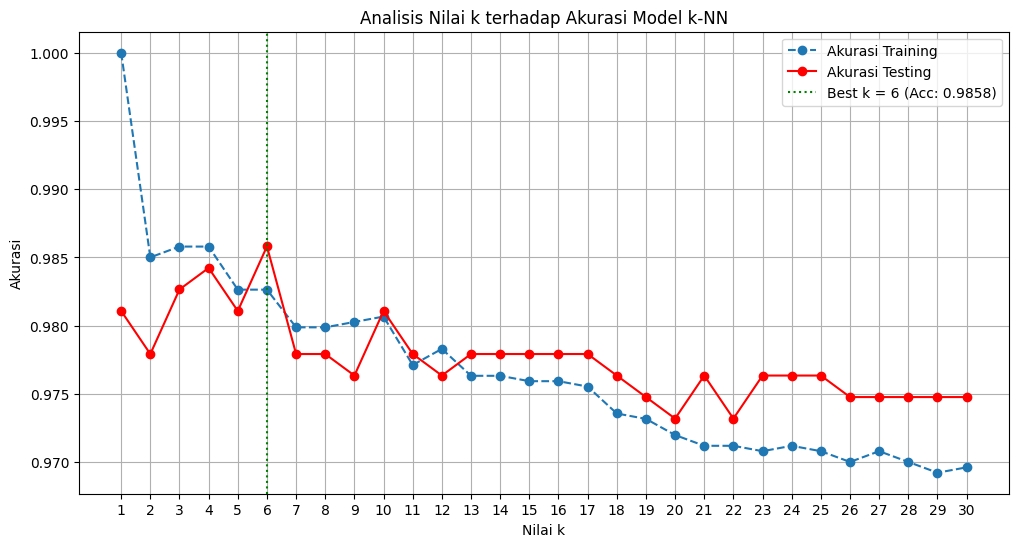

Nilai k terbaik adalah 6 dengan akurasi pengujian sebesar 0.9858


In [4]:
k_values = list(range(1, 31))
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_opt, y_train)

    # Akurasi Training
    train_preds = knn.predict(X_train_opt)
    train_accuracies.append(accuracy_score(y_train, train_preds))

    # Akurasi Testing
    test_preds = knn.predict(X_test_opt)
    test_accuracies.append(accuracy_score(y_test, test_preds))

# Menemukan k terbaik berdasarkan akurasi testing
best_k_idx = np.argmax(test_accuracies)
best_k = k_values[best_k_idx]
best_acc = test_accuracies[best_k_idx]

# Plotting Analisis k
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_accuracies, label='Akurasi Training', marker='o', linestyle='--')
plt.plot(k_values, test_accuracies, label='Akurasi Testing', marker='o', color='red')
plt.axvline(x=best_k, color='green', linestyle=':', label=f'Best k = {best_k} (Acc: {best_acc:.4f})')
plt.title('Analisis Nilai k terhadap Akurasi Model k-NN')
plt.xlabel('Nilai k')
plt.ylabel('Akurasi')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

print(f"Nilai k terbaik adalah {best_k} dengan akurasi pengujian sebesar {best_acc:.4f}")